# Aggregation propensity of misfolded GDI1 states

**Definition.** For state *i*,

    propensity_i = ( <SASA>_i - <SASA>_native ) / <SASA>_native * 100%

where SASA is summed over the **aggregation-prone regions (APRs)** predicted by AmylPred2.
Native is 0 by construction; larger values mean more APR surface exposed to solvent, i.e.
a greater opportunity to aggregate.

APRs are the AmylPred2 CONSENSUS4 hits (>=4 of 8 methods, the set AmylPred2 marks with
`>--->`), keeping only segments of >=5 residues since amyloid nucleation requires roughly
a hexapeptide. Three of them survive at CONSENSUS6/7 and are also the only TANGO hits —
216-221, 343-347, 360-368 — and are flagged as the high-confidence core.


**Read-only** on `cg_sim_300K/`. Outputs go to `R1_analysis/M3_APR/outputs/`.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import mdtraj as md
import matplotlib as mpl
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("/storage/home/qzv5006/group/Research_data/Aging_project")
SIM_DIR = PROJECT_ROOT / "cg_sim_300K/sc_ent/14_P39958"
SASA_PATH = SIM_DIR / "analysis/SASA/SASA.npy"
MSM_PATH = SIM_DIR / "analysis/msm_results/msm_analysis_results.npz"
QG_PATH = SIM_DIR / "analysis/QG.npy"
PDB_PATH = SIM_DIR / "template/setup/P39958_clean.pdb"

OUT_DIR = PROJECT_ROOT / "R1_analysis/M3_APR/outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

N_RESIDUES = 451
N_LAST_200NS = 2666
FRAME_PS = 75.0

NATIVE_RAW = 5
EXCLUDED_RAW = [1]
G_THRESHOLD = 0.0

N_BOOT = 10_000
N_PERM = 10_000
BOOT_CHUNK = 200
SEED = 20260809

to_reported = lambda raw: int(raw) + 1

# AmylPred2 CONSENSUS4 hits, 1-based inclusive, segments >= 5 residues.
# core=True marks segments also hit at CONSENSUS6/7 and by TANGO.
APRS = [
    ("APR1", 10, 18, False),
    ("APR2", 21, 28, False),
    ("APR3", 96, 103, False),
    ("APR4", 216, 222, True),
    ("APR5", 308, 317, False),
    ("APR6", 328, 332, False),
    ("APR7", 342, 349, True),
    ("APR8", 359, 368, True),
    ("APR9", 430, 435, False),
]

# Tien et al. 2013 theoretical maximum ASA (A^2); /100 -> nm^2
MAX_ASA = {
    "ALA": 129, "ARG": 274, "ASN": 195, "ASP": 193, "CYS": 167,
    "GLU": 223, "GLN": 225, "GLY": 104, "HIS": 224, "ILE": 197,
    "LEU": 201, "LYS": 236, "MET": 224, "PHE": 240, "PRO": 159,
    "SER": 155, "THR": 172, "TRP": 285, "TYR": 263, "VAL": 174,
}

mpl.rcParams.update({
    "font.size": 8, "axes.labelsize": 8, "axes.titlesize": 8,
    "xtick.labelsize": 8, "ytick.labelsize": 8,
    "axes.linewidth": 0.8, "pdf.fonttype": 42, "ps.fonttype": 42,
    "figure.dpi": 120, "savefig.dpi": 600, "savefig.bbox": "tight",
})

print("outputs ->", OUT_DIR)

outputs -> /storage/home/qzv5006/group/Research_data/Aging_project/R1_analysis/M3_APR/outputs


## Load inputs, verify the AmylPred2 numbering

The AmylPred2 sequence must match the structure residue-for-residue, otherwise every APR
index is silently wrong. Position `p` maps to SASA residue index `p-1`.

In [2]:
AMYLPRED_SEQ = (
    "MDQETIDTDYDVIVLGTGITECILSGLLSVDGKKVLHIDKQDHYGGEAAS"
    "VTLSQLYEKFKQNPISKEERESKFGKDRDWNVDLIPKFLMANGELTNILI"
    "HTDVTRYVDFKQVSGSYVFKQGKIYKVPANEIEAISSPLMGIFEKRRMKK"
    "FLEWISSYKEDDLSTHQGLDLDKNTMDEVYYKFGLGNSTKEFIGHAMALW"
    "TNDDYLQQPARPSFERILLYCQSVARYGKSPYLYPMYGLGELPQGFARLS"
    "AIYGGTYMLDTPIDEVLYKKDTGKFEGVKTKLGTFKAPLVIADPTYFPEK"
    "CKSTGQRVIRAICILNHPVPNTSNADSLQIIIPQSQLGRKSDIYVAIVSD"
    "AHNVCSKGHYLAIISTIIETDKPHIELEPAFKLLGPIEEKFMGIAELFEP"
    "REDGSKDNIYLSRSYDASSHFESMTDDVKDIYFRVTGHPLVLKQRQEQEK"
    "Q"
)
THREE2ONE = {"ALA": "A", "ARG": "R", "ASN": "N", "ASP": "D", "CYS": "C",
             "GLN": "Q", "GLU": "E", "GLY": "G", "HIS": "H", "ILE": "I",
             "LEU": "L", "LYS": "K", "MET": "M", "PHE": "F", "PRO": "P",
             "SER": "S", "THR": "T", "TRP": "W", "TYR": "Y", "VAL": "V"}

top = md.load(str(PDB_PATH)).topology
resnames = np.array([r.name for r in top.residues])
pdb_seq = "".join(THREE2ONE[n] for n in resnames)

assert top.n_residues == N_RESIDUES
assert pdb_seq == AMYLPRED_SEQ, "AmylPred2 sequence does not match the structure!"
assert [r.resSeq for r in top.residues] == list(range(1, N_RESIDUES + 1))
print("sequence check: AmylPred2 == P39958_clean.pdb, 451 residues, resSeq 1-451")
print("mapping: AmylPred2 position p -> SASA residue index p-1")

sasa_mm = np.load(SASA_PATH, mmap_mode="r")
meta_full = np.load(MSM_PATH, allow_pickle=True)["meta_dtrajs"]
qg_full = np.load(QG_PATH)
n_traj, n_frames_msm = meta_full.shape
assert sasa_mm.shape == (n_traj, n_frames_msm + 1, N_RESIDUES)

# drop the orphan last SASA frame FIRST, then take the last 200 ns
start = n_frames_msm - N_LAST_200NS
sasa_win = np.asarray(sasa_mm[:, start:n_frames_msm, :], dtype=np.float64)
meta_win = np.asarray(meta_full[:, -N_LAST_200NS:])
G_win = qg_full[:, -N_LAST_200NS:, 1]
print(f"\nSASA window {sasa_win.shape}, meta window {meta_win.shape}")

sequence check: AmylPred2 == P39958_clean.pdb, 451 residues, resSeq 1-451
mapping: AmylPred2 position p -> SASA residue index p-1


/storage/group/epo2/default/qzv5006/miniconda3/envs/bioenv/lib/python3.13/site-packages/mdtraj/formats/pdb/pdbfile.py:214: UserWarning: Unlikely unit cell vectors detected in PDB file likely resulting from a dummy CRYST1 record. Discarding unit cell vectors.
  warnings.warn(



SASA window (50, 2666, 451), meta window (50, 2666)


## APR definitions

`max_sasa_nm2` is the sum of Tien et al. maximum ASA over each APR's residues — the value
the APR would have if fully extended and solvent-exposed. Dividing the observed SASA by it
gives a relative exposure (RSA) between 0 and 1, which is what makes APRs of different
length and composition comparable to each other.

In [3]:
apr_rows = []
for name, a, b, core in APRS:
    idx = np.arange(a - 1, b)                      # 0-based residue indices
    seq = "".join(THREE2ONE[n] for n in resnames[idx])
    max_sasa = sum(MAX_ASA[n] for n in resnames[idx]) / 100.0   # A^2 -> nm^2
    apr_rows.append({
        "apr": name, "start": a, "end": b, "length": len(idx),
        "sequence": seq, "core": core, "max_sasa_nm2": max_sasa,
    })

apr_df = pd.DataFrame(apr_rows)
apr_df.to_csv(OUT_DIR / "apr_definitions.csv", index=False)

apr_idx = {r["apr"]: np.arange(r["start"] - 1, r["end"]) for _, r in apr_df.iterrows()}
union_idx = np.unique(np.concatenate(list(apr_idx.values())))
union_max = sum(MAX_ASA[n] for n in resnames[union_idx]) / 100.0

print(f"{len(apr_df)} APRs, {len(union_idx)} residues total "
      f"({100 * len(union_idx) / N_RESIDUES:.1f}% of the protein)")
apr_df

9 APRs, 71 residues total (15.7% of the protein)


,apr,start,end,length,sequence,core,max_sasa_nm2
0,APR1,10,18,9,YDVIVLGTG,False,15.82
1,APR2,21,28,8,ECILSGLL,False,14.49
2,APR3,96,103,8,TNILIHTD,False,15.51
3,APR4,216,222,7,RILLYCQ,True,15.28
4,APR5,308,317,10,VIRAICILNH,False,19.55
5,APR6,328,332,5,LQIII,False,10.17
6,APR7,342,349,8,DIYVAIVS,True,14.82
7,APR8,359,368,10,HYLAIISTII,True,19.32
8,APR9,430,435,6,DIYFRV,False,13.41


## Per-frame APR SASA

`total_apr_sasa` is `(50, 2666)` — the SASA summed over the union of all APR residues in
each frame. This single quantity is what the aggregation propensity is defined on.

In [4]:
total_apr_sasa = sasa_win[:, :, union_idx].sum(axis=2)

print(f"total_apr_sasa {total_apr_sasa.shape}")
print(f"range {total_apr_sasa.min():.1f} - {total_apr_sasa.max():.1f} nm^2")
print(f"union max possible SASA: {union_max:.1f} nm^2")

total_apr_sasa (50, 2666)
range 12.3 - 60.1 nm^2
union max possible SASA: 138.4 nm^2


## Frame masks

Same rule as the population figure and `R1_analysis/M3/`: non-native frames require
`G > 0`, native frames are unfiltered.

In [5]:
raw_states = np.unique(meta_full).tolist()
NATIVE_REP = to_reported(NATIVE_RAW)
ANALYZED = [to_reported(r) for r in raw_states if r not in EXCLUDED_RAW]


def state_mask(raw):
    base = meta_win == raw
    return base if raw == NATIVE_RAW else base & (G_win > G_THRESHOLD)


masks = {to_reported(raw): state_mask(raw) for raw in raw_states}
for rep in sorted(masks):
    tag = "   <- native" if rep == NATIVE_REP else ""
    tag += "   <- EXCLUDED" if rep - 1 in EXCLUDED_RAW else ""
    print(f"state {rep}: {int(masks[rep].sum()):>6d} frames{tag}")

state 1:   5252 frames
state 2:      2 frames   <- EXCLUDED
state 3:   2691 frames
state 4:  25237 frames
state 5:   9426 frames
state 6:  71879 frames   <- native


## Aggregation propensity

    propensity_i = ( <S>_i - <S>_nat ) / <S>_nat * 100%

on total APR SASA. Native is 0 by definition.

The confidence interval comes from bootstrapping the state's frames; the native mean is
treated as fixed because it is estimated from ~72,000 frames and its own relative error is
~0.03%, two orders of magnitude below the state-level effects. The permutation test is the
same pooled-frame test used in M3.

In [6]:
def bootstrap_mean(values, n_boot=N_BOOT, seed=SEED, chunk=BOOT_CHUNK):
    """Bootstrap distribution of the mean, resampling frames."""
    values = np.asarray(values, dtype=float)
    n = len(values)
    rng = np.random.default_rng(seed)
    out = np.empty(n_boot)
    done = 0
    while done < n_boot:
        k = min(chunk, n_boot - done)
        out[done:done + k] = values[rng.integers(0, n, size=(k, n))].mean(axis=1)
        done += k
    return out


def permutation_test(x, y, n_perm=N_PERM, seed=SEED):
    """Two-sided permutation test on the difference of means."""
    x, y = np.asarray(x, float), np.asarray(y, float)
    n_x, n_y = len(x), len(y)
    if n_x < 2 or n_y < 2:
        return np.nan
    rng = np.random.default_rng(seed)
    observed = x.mean() - y.mean()
    combined = np.concatenate([x, y])
    total = combined.sum()
    ge = 0
    for _ in range(n_perm):
        s = rng.permutation(combined)[:n_x].sum()
        ge += abs(s / n_x - (total - s) / n_y) >= abs(observed)
    return (1 + ge) / (1 + n_perm)


nat_vals = total_apr_sasa[masks[NATIVE_REP]]
nat_mean = nat_vals.mean()

rows = []
for rep in ANALYZED:
    v = total_apr_sasa[masks[rep]]
    boot_prop = (bootstrap_mean(v) - nat_mean) / nat_mean * 100
    lo, hi = np.percentile(boot_prop, [2.5, 97.5])
    p = np.nan if rep == NATIVE_REP else permutation_test(v, nat_vals)
    rows.append({
        "state_raw": rep - 1, "state_reported": rep,
        "is_native": rep == NATIVE_REP, "n_frames": len(v),
        "mean_apr_sasa": v.mean(),
        "rsa": v.mean() / union_max,
        "propensity_pct": (v.mean() - nat_mean) / nat_mean * 100,
        "ci95_low": lo, "ci95_high": hi, "p_two_sided": p,
    })

propensity = pd.DataFrame(rows).sort_values("state_reported")
propensity.to_csv(OUT_DIR / "aggregation_propensity.csv", index=False)
propensity.round(3)

,state_raw,state_reported,is_native,n_frames,mean_apr_sasa,rsa,propensity_pct,ci95_low,ci95_high,p_two_sided
0,0,1,False,5252,47.411,0.343,181.460,180.963,181.961,0.0
1,2,3,False,2691,26.248,0.190,55.820,55.269,56.362,0.0
2,3,4,False,25237,17.260,0.125,2.466,2.371,2.565,0.0
3,4,5,False,9426,17.401,0.126,3.301,3.139,3.462,0.0
4,5,6,True,71879,16.845,0.122,0.000,-0.056,0.056,NaN


## Figure

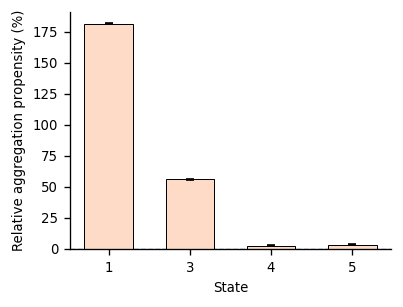

In [7]:
# --- propensity by state -----------------------------------------------------
fig, ax = plt.subplots(figsize=(3.4, 2.6))
sub = propensity[propensity["state_reported"] != NATIVE_REP]
x = list(range(len(sub)))
ax.bar(x, sub["propensity_pct"], width=0.6, color="#fddbc7",
       edgecolor="black", lw=0.6, zorder=2)
ax.errorbar(x, sub["propensity_pct"],
            yerr=[sub["propensity_pct"] - sub["ci95_low"],
                  sub["ci95_high"] - sub["propensity_pct"]],
            fmt="none", ecolor="black", capsize=2.5, lw=0.8, zorder=3)
ax.axhline(0, color="#2166ac", ls="--", lw=0.8, zorder=1)
ax.set_xticks(x)
ax.set_xticklabels(sub["state_reported"])
ax.set_xlabel("State")
ax.set_ylabel("Relative aggregation propensity (%)")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(OUT_DIR / "aggregation_propensity.png")
fig.savefig(OUT_DIR / "aggregation_propensity.pdf")
plt.show()

## Report

In [8]:
lines = [
    "# Aggregation propensity of misfolded GDI1 states",
    "",
    "## Definition",
    "",
    "For state i, aggregation propensity = ( <SASA>_i - <SASA>_native ) / <SASA>_native "
    "x 100%, where SASA is summed over the union of AmylPred2-predicted aggregation-prone "
    f"regions ({len(union_idx)} residues across {len(apr_df)} APRs). Native is 0 by "
    "construction; larger values mean more APR surface exposed to solvent.",
    "",
    "## Methods",
    "",
    "APRs are AmylPred2 CONSENSUS4 hits (>=4 of 8 methods) of length >=5 residues. The "
    "AmylPred2 sequence was verified identical to the simulated structure "
    "(P39958_clean.pdb, 451 residues, resSeq 1-451), so AmylPred2 position p maps to "
    "residue index p-1. SASA is the existing per-residue Shrake-Rupley output on the "
    f"backmapped heavy-atom trajectories, restricted to the final "
    f"{N_LAST_200NS * FRAME_PS / 1000:.0f} ns ({N_LAST_200NS} frames at {FRAME_PS:g} "
    f"ps/frame) of {n_traj} trajectories. Non-native frames require G > 0 and native "
    "frames are unfiltered, matching the frame selection of the reported state "
    f"populations. Statistics are pooled over frames; CIs are percentile bootstrap "
    f"({N_BOOT:,} resamples) with the native mean treated as fixed, and p-values are "
    f"permutation tests ({N_PERM:,} permutations). State 2 is not populated in the final "
    "200 ns and is absent from all comparisons.",
    "",
    "## APR definitions",
    "",
    apr_df.drop(columns=["max_sasa_nm2"]).to_markdown(index=False),
    "",
    "## Aggregation propensity by state",
    "",
    propensity.drop(columns=["rsa"]).round(3).to_markdown(index=False),
    "",
    "## Interpretation",
    "",
    "TODO - write from the numbers above.",
    "",
    "Caveats: SASA is computed on the monomer, so this is an aggregation *propensity* "
    "proxy and not aggregation; residue-level SASA includes backbone as well as side "
    "chain; frames 75 ps apart are autocorrelated, so pooled-frame CIs are narrow and "
    "p-values bottom out at the permutation floor; and AmylPred2 predictions are "
    "sequence-based, carrying their own false-positive rate.",
    "",
]

(OUT_DIR / "aggregation_propensity_report.md").write_text("\n".join(lines))
print("wrote", OUT_DIR / "aggregation_propensity_report.md")

wrote /storage/home/qzv5006/group/Research_data/Aging_project/R1_analysis/M3_APR/outputs/aggregation_propensity_report.md
